In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [11]:
df.shape

(714, 3)

In [12]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [13]:
x.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [14]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [17]:
x_train,x_test,y_train,y_test=train_test_split(
        x,
        y,
        test_size=0.2,
        random_state=0
)

In [18]:
x_train.head()

,Age,Fare
387,36.0,13.0000
685,25.0,41.5792
20,35.0,26.0000
331,45.5,28.5000
396,31.0,7.8542


In [20]:
y_train.head()

387    1
685    0
20     0
331    0
396    0
Name: Survived, dtype: int64

In [21]:
clf=DecisionTreeClassifier()

In [22]:
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

In [29]:
accuracy_score(y_test,y_pred)

0.6153846153846154

In [30]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6274647887323944)

In [31]:
kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [33]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [35]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.fit_transform(x_test)

In [36]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  4.  , 17.  , 20.  , 22.  , 24.  , 26.  , 28.  , 30.  ,
              33.  , 36.  , 38.  , 40.  , 45.  , 57.  , 65.  ])             ],
      dtype=object)

In [37]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.65  ,   7.875 ,   8.1583,   9.5   ,  12.275 ,
               13.    ,  14.4542,  19.5   ,  26.25  ,  29.125 ,  39.6875,
               66.6   ,  79.65  , 135.6333, 263.    ])                   ],
      dtype=object)

In [41]:
output=pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})

In [43]:
output.head()

,age,age_trf,fare,fare_trf
387,36.0,10.0,13.0000,6.0
685,25.0,6.0,41.5792,12.0
20,35.0,10.0,26.0000,9.0
331,45.5,12.0,28.5000,10.0
396,31.0,9.0,7.8542,2.0


In [46]:
output['age_lables']=pd.cut(x=x_train['Age'],
                            bins=trf.named_transformers_['first'].bin_edges_[0].tolist())   # pd.cut(x, bins)
output['fare_lables']=pd.cut(x=x_train['Fare'],
                             bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [47]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_lables,fare_lables
14,14.0,1.0,7.8542,2.0,"(4.0, 17.0]","(7.65, 7.875]"
56,21.0,4.0,10.5000,5.0,"(20.0, 22.0]","(9.5, 12.275]"
503,37.0,11.0,9.5875,5.0,"(36.0, 38.0]","(9.5, 12.275]"
675,18.0,3.0,7.7750,2.0,"(17.0, 20.0]","(7.65, 7.875]"
514,24.0,5.0,7.4958,1.0,"(22.0, 24.0]","(0.0, 7.65]"


In [48]:
clf=DecisionTreeClassifier()

clf.fit(x_train_trf,y_train)
y_pred2=clf.predict(x_test_trf)

accuracy_score(y_test,y_pred2)

0.5874125874125874

In [50]:
x_trf=trf.fit_transform(x)

np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6274843505477309)

In [56]:
def Descretize(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=5, encode='ordinal', strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=5,encode='ordinal',strategy=strategy)

    ## Column Transfromer
    trf=ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ], remainder='passthrough'
    )

    x_trf=trf.fit_transform(x)

    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(12,5))

    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(12,5))

    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,1])
    plt.title("After",color='red')

    plt.show()

0.6345070422535211


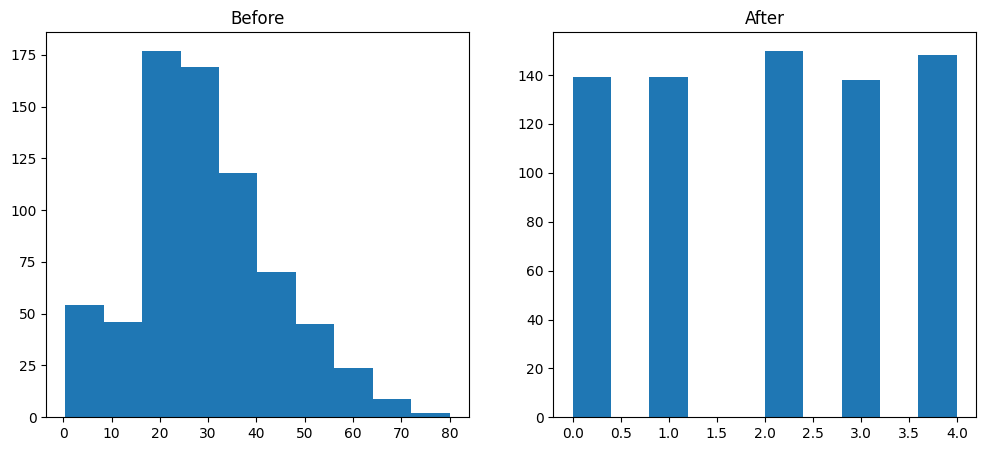

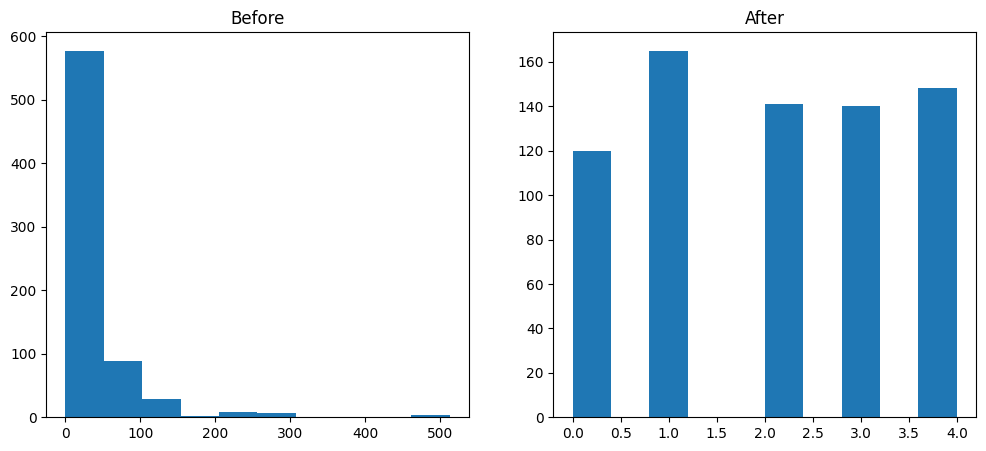

In [55]:
Descretize(10,'quantile')